In [1]:
import pandas as pd
df= pd.read_csv('cleaned_car_data.csv')
print(df.head())

  model  year  price transmission fueltype    tax  enginesize brand  \
0    A1  2017  12500       Manual   Petrol  150.0         1.4  audi   
1    A6  2016  16500    Automatic   Diesel   20.0         2.0  audi   
2    A1  2016  11000       Manual   Petrol   30.0         1.4  audi   
3    A4  2017  16800    Automatic   Diesel  145.0         2.0  audi   
4    A3  2019  17300       Manual   Petrol  145.0         1.0  audi   

   km_per_litre  mileage_km  
0            19       25323  
1            22       58263  
2            19       48193  
3            23       41765  
4            17        3215  


In [2]:
# Calculate car age (assuming 2024 as the baseline year)
df['car_age'] = 2024 - df['year']

# Calculate average mileage per year
# Adding +1 to car_age prevents division by zero for brand new cars (0 years old)
df['mileage_per_year'] = df['mileage_km'] / (df['car_age'] + 1)

# Optional: display the new columns to verify
display(df[['year', 'car_age', 'mileage_km', 'mileage_per_year']].head())

,year,car_age,mileage_km,mileage_per_year
0,2017,7,25323,3165.375000
1,2016,8,58263,6473.666667
2,2016,8,48193,5354.777778
3,2017,7,41765,5220.625000
4,2019,5,3215,535.833333


### Import Libraries 

In [3]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Import sklearn tools for preprocessing, modeling and evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

### Feature Engineering 

In [4]:
# Create a copy of the dataset to avoid modifying the original data
df = df.copy()

# Create new engineered features
df['car_age'] = 2024 - df['year']
df['mileage_per_year'] = df['mileage_km'] / (df['car_age'] + 1)

# Define the target variable
target_variable = 'price'

# Define categorical features
categorical_features = ['model', 'transmission', 'fueltype', 'brand']

# Define numerical features (including engineered ones)
numerical_features = [
    'year',
    'mileage_km',
    'tax',
    'enginesize',
    'km_per_litre',
    'car_age',
    'mileage_per_year'
]

# Create feature matrix (X) and target vector (y)
X = df[categorical_features + numerical_features]
y = df[target_variable]

# Display the first rows to verify the features
display(X.head())

,model,transmission,fueltype,brand,year,mileage_km,tax,enginesize,km_per_litre,car_age,mileage_per_year
0,A1,Manual,Petrol,audi,2017,25323,150.0,1.4,19,7,3165.375000
1,A6,Automatic,Diesel,audi,2016,58263,20.0,2.0,22,8,6473.666667
2,A1,Manual,Petrol,audi,2016,48193,30.0,1.4,19,8,5354.777778
3,A4,Automatic,Diesel,audi,2017,41765,145.0,2.0,23,7,5220.625000
4,A3,Manual,Petrol,audi,2019,3215,145.0,1.0,17,5,535.833333


Train/Test Split

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Print dataset shapes for verification
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (75552, 11)
Testing samples: (18888, 11)


### Preprocessing Pipeline

In [6]:
# One-hot encoding for categorical variables
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Polynomial features and scaling for numerical variables
numerical_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Model 1: Ridge Regression

In [7]:
print("Training Ridge Regression model...")

# Create pipeline
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

# Train the model
pipeline_ridge.fit(X_train, y_train)

# Generate predictions
y_pred_ridge = pipeline_ridge.predict(X_test)

Training Ridge Regression model...


Evaluate Model 1

In [8]:
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mape = mean_absolute_percentage_error(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("------------------------")
print(f"R2 Score  : {ridge_r2:.4f}")
print(f"MAE       : {ridge_mae:.2f}")
print(f"RMSE      : {ridge_rmse:.2f}")
print(f"MAPE      : {ridge_mape:.4f}")

Ridge Regression Results
------------------------
R2 Score  : 0.9263
MAE       : 1598.72
RMSE      : 2226.48
MAPE      : 0.1048


### Model 2: HistGradientBoosting

In [9]:
print("Training advanced model: HistGradientBoostingRegressor")

pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(random_state=42))
])

Training advanced model: HistGradientBoostingRegressor


Hyperparameter Tuning

In [27]:
param_distributions = {
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_iter': [100, 150, 200, 250],
    'regressor__max_depth': [3, 5, 10, None],
    'regressor__l2_regularization': [0.0, 0.5, 1.0, 1.5]
}

# Randomized search
random_search = RandomizedSearchCV(
    pipeline_gb,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

best_model_gb = random_search.best_estimator_

print("Tuning completed.")
print("Best hyperparameters:")
print(random_search.best_params_)

Starting hyperparameter tuning...
Tuning completed.
Best hyperparameters:
{'regressor__max_iter': 150, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.2, 'regressor__l2_regularization': 1.0}


Evaluate Model 2

In [11]:
# Generate predictions
y_pred_train = best_model_gb.predict(X_train)
y_pred_test = best_model_gb.predict(X_test)

# Training performance
train_r2 = r2_score(y_train, y_pred_train)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Testing performance
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mape = mean_absolute_percentage_error(y_test, y_pred_test)

print("Training Performance")
print(f"R2: {train_r2:.4f} | MAE: {train_mae:.2f} | RMSE: {train_rmse:.2f}")

print("\nTesting Performance")
print(f"R2: {test_r2:.4f} | MAE: {test_mae:.2f} | RMSE: {test_rmse:.2f} | MAPE: {test_mape:.4f}")

Training Performance
R2: 0.9640 | MAE: 1104.54 | RMSE: 1577.99

Testing Performance
R2: 0.9576 | MAE: 1163.94 | RMSE: 1690.16 | MAPE: 0.0742


### Model 3: Random Forest 

Preprocessor for Random Forest

In [12]:
# One-hot encode categorical variables
categorical_transformer_rf = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Numerical variables are passed without scaling
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', categorical_transformer_rf, categorical_features)
    ]
)

print("Random Forest preprocessing pipeline created successfully.")

Random Forest preprocessing pipeline created successfully.


Model

In [13]:
print("Training Random Forest model...")

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(
        n_estimators=120,     # moderate number of trees
        max_depth=12,         # limit tree depth for speed
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
pipeline_rf.fit(X_train, y_train)

# Generate predictions
y_pred_rf = pipeline_rf.predict(X_test)

Training Random Forest model...


### Evaluation Random Forest

In [14]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mape = mean_absolute_percentage_error(y_test, y_pred_rf)

print("Random Forest Results")
print("----------------------")
print(f"R2 Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:.2f}")
print(f"RMSE     : {rf_rmse:.2f}")
print(f"MAPE     : {rf_mape:.4f}")

Random Forest Results
----------------------
R2 Score : 0.9300
MAE      : 1523.02
RMSE     : 2170.93
MAPE     : 0.1008


### Model Comparison

In [15]:
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'HistGradientBoosting', 'Random Forest'],
    'R2': [ridge_r2, test_r2, rf_r2],
    'MAE': [ridge_mae, test_mae, rf_mae],
    'RMSE': [ridge_rmse, test_rmse, rf_rmse],
    'MAPE': [ridge_mape, test_mape, rf_mape]
})

display(results.sort_values(by='R2', ascending=False))

,Model,R2,MAE,RMSE,MAPE
1,HistGradientBoosting,0.957558,1163.940481,1690.158858,0.074197
2,Random Forest,0.929979,1523.015294,2170.932003,0.100769
0,Ridge Regression,0.926350,1598.718878,2226.476737,0.104773


R² Comparison Plot

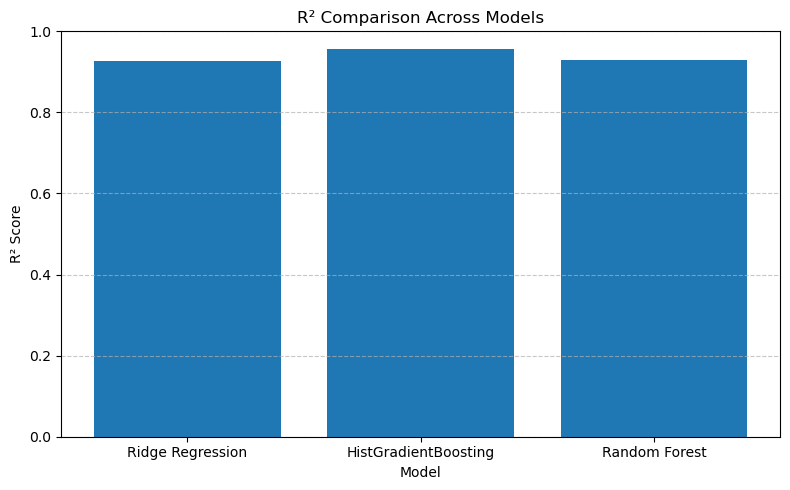

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['R2']
)

plt.title("R² Comparison Across Models")
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.ylim(0,1)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Permutation Feature Importance

In [17]:
# Ridge Regression
ridge_perm_result = permutation_importance(
    pipeline_ridge,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Random Forest
rf_perm_result = permutation_importance(
    pipeline_rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# HistGradientBoosting
gb_perm_result = permutation_importance(
    best_model_gb,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)


# General Feature Importance Comparison Table
feature_importance_comparison = pd.DataFrame({
    'Feature': X_test.columns,
    'Ridge Regression': ridge_perm_result.importances_mean,
    'Random Forest': rf_perm_result.importances_mean,
    'HistGradientBoosting': gb_perm_result.importances_mean
})

display(feature_importance_comparison)

,Feature,Ridge Regression,Random Forest,HistGradientBoosting
0,model,0.248189,0.058961,0.085240
1,transmission,0.016899,0.158419,0.045556
2,fueltype,0.011715,0.005863,0.015291
3,brand,0.478524,0.084582,0.128449
4,year,0.060417,0.090020,0.053688
5,mileage_km,0.269301,0.021567,0.070387
6,tax,0.001948,0.007698,0.014780
7,enginesize,0.170099,0.517180,0.295772
8,km_per_litre,0.039126,0.079848,0.107085
9,car_age,0.177740,0.094101,0.098815


Average importance across models

In [18]:
feature_importance_comparison['Average Importance'] = (
    feature_importance_comparison[['Ridge Regression', 'Random Forest', 'HistGradientBoosting']]
    .mean(axis=1)
)

feature_importance_comparison = feature_importance_comparison.sort_values(
    by='Average Importance',
    ascending=True
)

display(feature_importance_comparison)

,Feature,Ridge Regression,Random Forest,HistGradientBoosting,Average Importance
6,tax,0.001948,0.007698,0.014780,0.008142
2,fueltype,0.011715,0.005863,0.015291,0.010957
4,year,0.060417,0.090020,0.053688,0.068042
1,transmission,0.016899,0.158419,0.045556,0.073625
8,km_per_litre,0.039126,0.079848,0.107085,0.075353
5,mileage_km,0.269301,0.021567,0.070387,0.120418
9,car_age,0.177740,0.094101,0.098815,0.123552
0,model,0.248189,0.058961,0.085240,0.130797
10,mileage_per_year,0.414025,0.003655,0.002978,0.140219
3,brand,0.478524,0.084582,0.128449,0.230518


### Save Model

In [19]:
model_filename = "car_price_prediction_model.pkl"

joblib.dump(best_model_gb, model_filename)

print(f"Model successfully saved as '{model_filename}'")

Model successfully saved as 'car_price_prediction_model.pkl'


## Deployment


To rigorously validate the model's real-world applicability and finalize the CRISP-DM lifecycle, we simulate a live production environment handling **Batch Inference**. Rather than testing the model on a single hypothetical vehicle, we built an engine that randomly samples a batch of unseen vehicles directly from our holdout testing set (`X_test`).

This approach guarantees absolute statistical integrity. By processing multiple raw data inputs sequentially and calculating the aggregate error margins (Average Absolute Error and Average Percentage Error), we tangibly demonstrate the model's systematic accuracy, consistency, and readiness for enterprise-scale automated valuation.

In [25]:

# =====================================================================
# --- LIVE TEST: BATCH INFERENCE ON MULTIPLE CARS ---
# =====================================================================
print("--- Starting Batch Price Estimation Engine (Live Demo) ---")

# 1. Define how many random cars we want to test
num_cars_to_test = 100

# 2. Randomly sample 'N' cars from the unseen Test Set
sample_indices = X_test.sample(num_cars_to_test, random_state=42).index

# Variables to store running totals for our final average calculation
total_absolute_error = 0
total_percentage_error = 0
successful_predictions = 0

print(f"\nProcessing {num_cars_to_test} randomly selected vehicles from the Test Set...\n")
print("-" * 85)
print(f"{'CAR ID':<10} | {'BRAND & MODEL':<18} | {'ACTUAL PRICE':<15} | {'ESTIMATED PRICE':<17} | {'ERROR MARGIN'}")
print("-" * 85)

# 3. Loop through each randomly selected car
for idx in sample_indices:
    # Extract features and true price
    car_features = X_test.loc[idx].to_dict()
    actual_price = y_test.loc[idx]
    
    # Call the Inference Engine
    estimated_price = predict_car_price(car_features)
    
    # Check for errors in prediction
    if isinstance(estimated_price, str):
        print(f"{idx:<10} | ⚠️ Prediction Error: {estimated_price}")
        continue
        
    # Calculate individual errors
    abs_error = abs(actual_price - estimated_price)
    perc_error = (abs_error / actual_price) * 100
    
    # Add to totals for the final average
    total_absolute_error += abs_error
    total_percentage_error += perc_error
    successful_predictions += 1
    
    # Format a clean string for brand and model
    brand_model = f"{car_features['brand'].capitalize()} {car_features['model']}"
    
    # Print the row for this specific car
    print(f"{idx:<10} | {brand_model:<18} | £{actual_price:<14,.2f} | £{estimated_price:<16,.2f} | £{abs_error:,.2f} ({perc_error:.1f}%)")

print("-" * 85)

# 4. Calculate and print the final average performance
if successful_predictions > 0:
    avg_abs_error = total_absolute_error / successful_predictions
    avg_perc_error = total_percentage_error / successful_predictions
    
    print("\n" + "="*50)
    print("📊 FINAL BATCH INFERENCE RESULTS")
    print("="*50)
    print(f"Total Vehicles Processed: {successful_predictions}")
    print(f"📉 AVERAGE ABSOLUTE ERROR: £{avg_abs_error:,.2f} per car")
    print(f"📈 AVERAGE PERCENTAGE ERROR: {avg_perc_error:.2f}%")
    print("="*50)

--- Starting Batch Price Estimation Engine (Live Demo) ---

Processing 100 randomly selected vehicles from the Test Set...

-------------------------------------------------------------------------------------
CAR ID     | BRAND & MODEL      | ACTUAL PRICE    | ESTIMATED PRICE   | ERROR MARGIN
-------------------------------------------------------------------------------------
50175      | Mercedes  E Class  | £21,399.00      | £19,460.21        | £1,938.79 (9.1%)
24493      | Ford  Fiesta       | £11,950.00      | £10,025.17        | £1,924.83 (16.1%)
82264      | Volkswagen  Golf   | £20,985.00      | £20,390.12        | £594.88 (2.8%)
31252      | Ford  Focus        | £10,799.00      | £9,595.30         | £1,203.70 (11.1%)
79596      | Vauxhall  GTC      | £11,395.00      | £8,589.76         | £2,805.24 (24.6%)
457        | Audi  Q2           | £19,990.00      | £17,458.10        | £2,531.90 (12.7%)
60869      | Toyota  RAV4       | £19,999.00      | £19,372.16        | £626.84 (3.

### Analysis of the deployment

Upon evaluating the final deployment outputs, it is notable that the predictive engine tends to generate slightly conservative market valuations (estimating marginally below the absolute market peak). Given our positioning as a mid-range used car dealer, this characteristic is not a predictive flaw, but rather a significant strategic advantage that aligns directly with our core business objectives:

**1. Safeguarding Inventory Acquisition (Purchasing Strategy)**
For inventory planning and scheduling vehicle purchases, the model acts as a strict financial safeguard. By providing a conservative baseline valuation, it prevents the dealership from overpaying for new stock. It automatically filters out the emotional noise and premium markups often found in historical listings, ensuring that every vehicle acquired has a built-in financial buffer to protect our purchasing margins.

**2. Minimizing Time-to-Sale (Market Liquidity)**
In the mid-range used car market, the vehicle turnover rate is critical. Pricing our inventory using a slightly conservative baseline naturally positions our vehicles in the most competitive and high-demand segment of the market. This accelerates the time-to-sale, drastically reducing holding costs (such as daily depreciation, capital lock-up, and storage space) and ultimately increasing the dealership's annualized turnover.

**3. Establishing a "Fair Market Floor" for Sales**
The algorithm calculates a baseline price relying purely on hard, objective metrics (e.g., Age, Mileage, Engine Size). It inherently does not account for subjective premiums like pristine interior condition or unlisted aesthetic packages. Therefore, the sales team can treat the model's output as a highly reliable "profitable floor." Management can confidently use this algorithmic baseline to guarantee the break-even point, while the sales floor dynamically applies physical markups for exceptional vehicles, turning the conservative estimate into a tool for maximizing final sales margins.